# __Reto 7: Distribuciones de las variables__

## Objetivo

Identificar los tipos de variables de un dataset, explicar cuales son, generar las distribuciones de cada una y calcular la media y la desviacion estandar.

## Tarea 1

Cargar datos. Vamos a trabajar con los datos 'House Prediction Rent' del reto 6.

In [41]:
# librerias
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt


In [2]:
df = pd.read_csv('./House_Rent_Dataset.csv')
df.head()

,Posted On,BHK,Rent,Size,Floor,Area Type,Area Locality,City,Furnishing Status,Tenant Preferred,Bathroom,Point of Contact
0,2022-05-18,2,10000,1100,Ground out of 2,Super Area,Bandel,Kolkata,Unfurnished,Bachelors/Family,2,Contact Owner
1,2022-05-13,2,20000,800,1 out of 3,Super Area,"Phool Bagan, Kankurgachi",Kolkata,Semi-Furnished,Bachelors/Family,1,Contact Owner
2,2022-05-16,2,17000,1000,1 out of 3,Super Area,Salt Lake City Sector 2,Kolkata,Semi-Furnished,Bachelors/Family,1,Contact Owner
3,2022-07-04,2,10000,800,1 out of 2,Super Area,Dumdum Park,Kolkata,Unfurnished,Bachelors/Family,1,Contact Owner
4,2022-05-09,2,7500,850,1 out of 2,Carpet Area,South Dum Dum,Kolkata,Unfurnished,Bachelors,1,Contact Owner


## Tarea 2

Clasificar las variables según su tipo.

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4746 entries, 0 to 4745
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   Posted On          4746 non-null   object
 1   BHK                4746 non-null   int64 
 2   Rent               4746 non-null   int64 
 3   Size               4746 non-null   int64 
 4   Floor              4746 non-null   object
 5   Area Type          4746 non-null   object
 6   Area Locality      4746 non-null   object
 7   City               4746 non-null   object
 8   Furnishing Status  4746 non-null   object
 9   Tenant Preferred   4746 non-null   object
 10  Bathroom           4746 non-null   int64 
 11  Point of Contact   4746 non-null   object
dtypes: int64(4), object(8)
memory usage: 445.1+ KB


In [5]:
# convertir Posted On a datetime
df['Posted On'] = pd.to_datetime(df['Posted On'], format='%Y-%m-%d')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4746 entries, 0 to 4745
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   Posted On          4746 non-null   datetime64[ns]
 1   BHK                4746 non-null   int64         
 2   Rent               4746 non-null   int64         
 3   Size               4746 non-null   int64         
 4   Floor              4746 non-null   object        
 5   Area Type          4746 non-null   object        
 6   Area Locality      4746 non-null   object        
 7   City               4746 non-null   object        
 8   Furnishing Status  4746 non-null   object        
 9   Tenant Preferred   4746 non-null   object        
 10  Bathroom           4746 non-null   int64         
 11  Point of Contact   4746 non-null   object        
dtypes: datetime64[ns](1), int64(4), object(7)
memory usage: 445.1+ KB


__Tipo Numéricas__

- BHK

- Rent

- Size

- Bathroom

__Tipo Categórica__

- Floor: ordinal

- Area Type: nominal

- Area Locality: nominal

- City: nominal

- Furnishing Status: nominal

- Tenant Preferred: ordinal

- Point of contact: nominal

__Tipo Tiempo__

- Posted On: fecha

## Tarea 3

Crear las distribuciones de las variables numericas.

__Histograma de BHK__

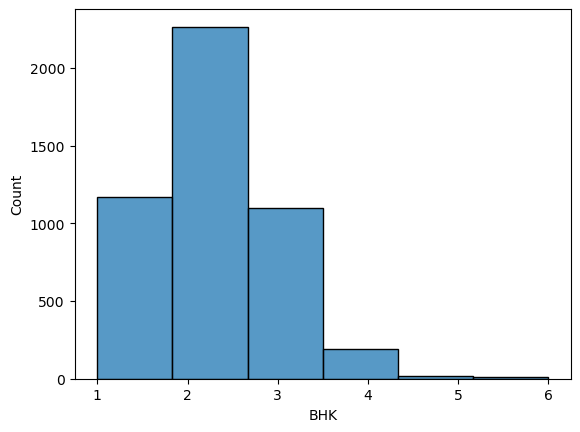

In [11]:
sns.histplot(df, x='BHK', bins=6);

__Diagrama de densidad de Rent__

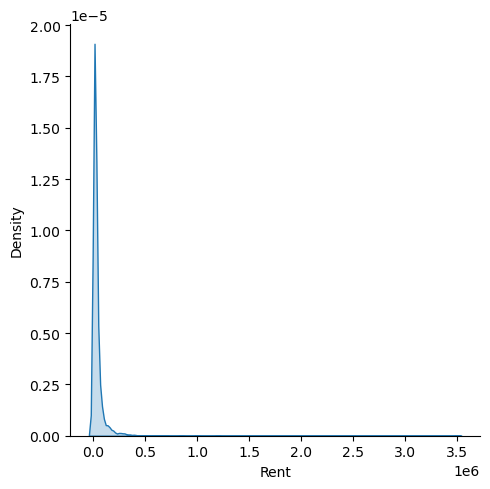

In [20]:
sns.displot(df, x='Rent', kind='kde', fill=True);

__Histograma de Size__

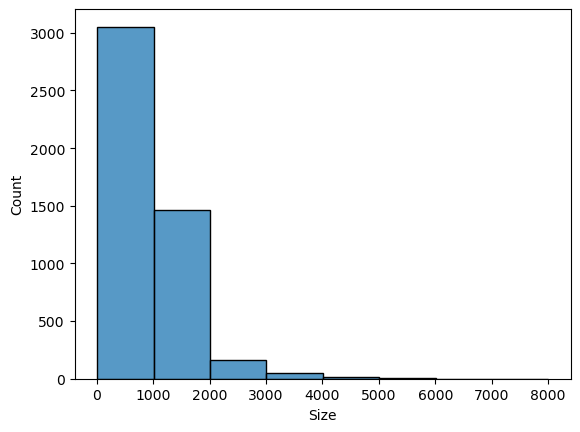

In [23]:
sns.histplot(df, x='Size', bins=8);

__Histograma de Bathroom__

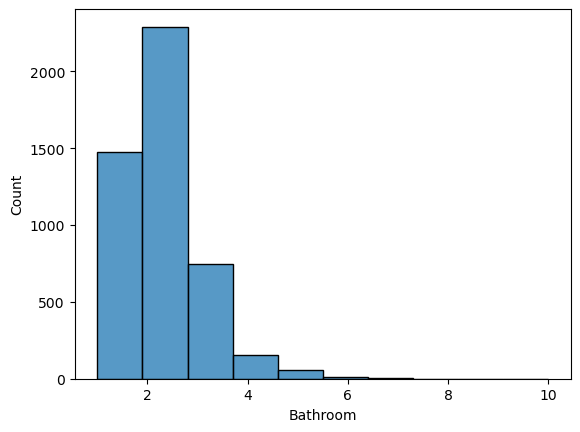

In [31]:
sns.histplot(df, x='Bathroom', bins=10);

## Tarea 4

Distribuciones de las variables categoricas

__Histograma de Floor__

In [37]:
df.Floor.unique

<bound method Series.unique of 0       Ground out of 2
1            1 out of 3
2            1 out of 3
3            1 out of 2
4            1 out of 2
             ...       
4741         3 out of 5
4742         1 out of 4
4743         3 out of 5
4744       23 out of 34
4745         4 out of 5
Name: Floor, Length: 4746, dtype: object>

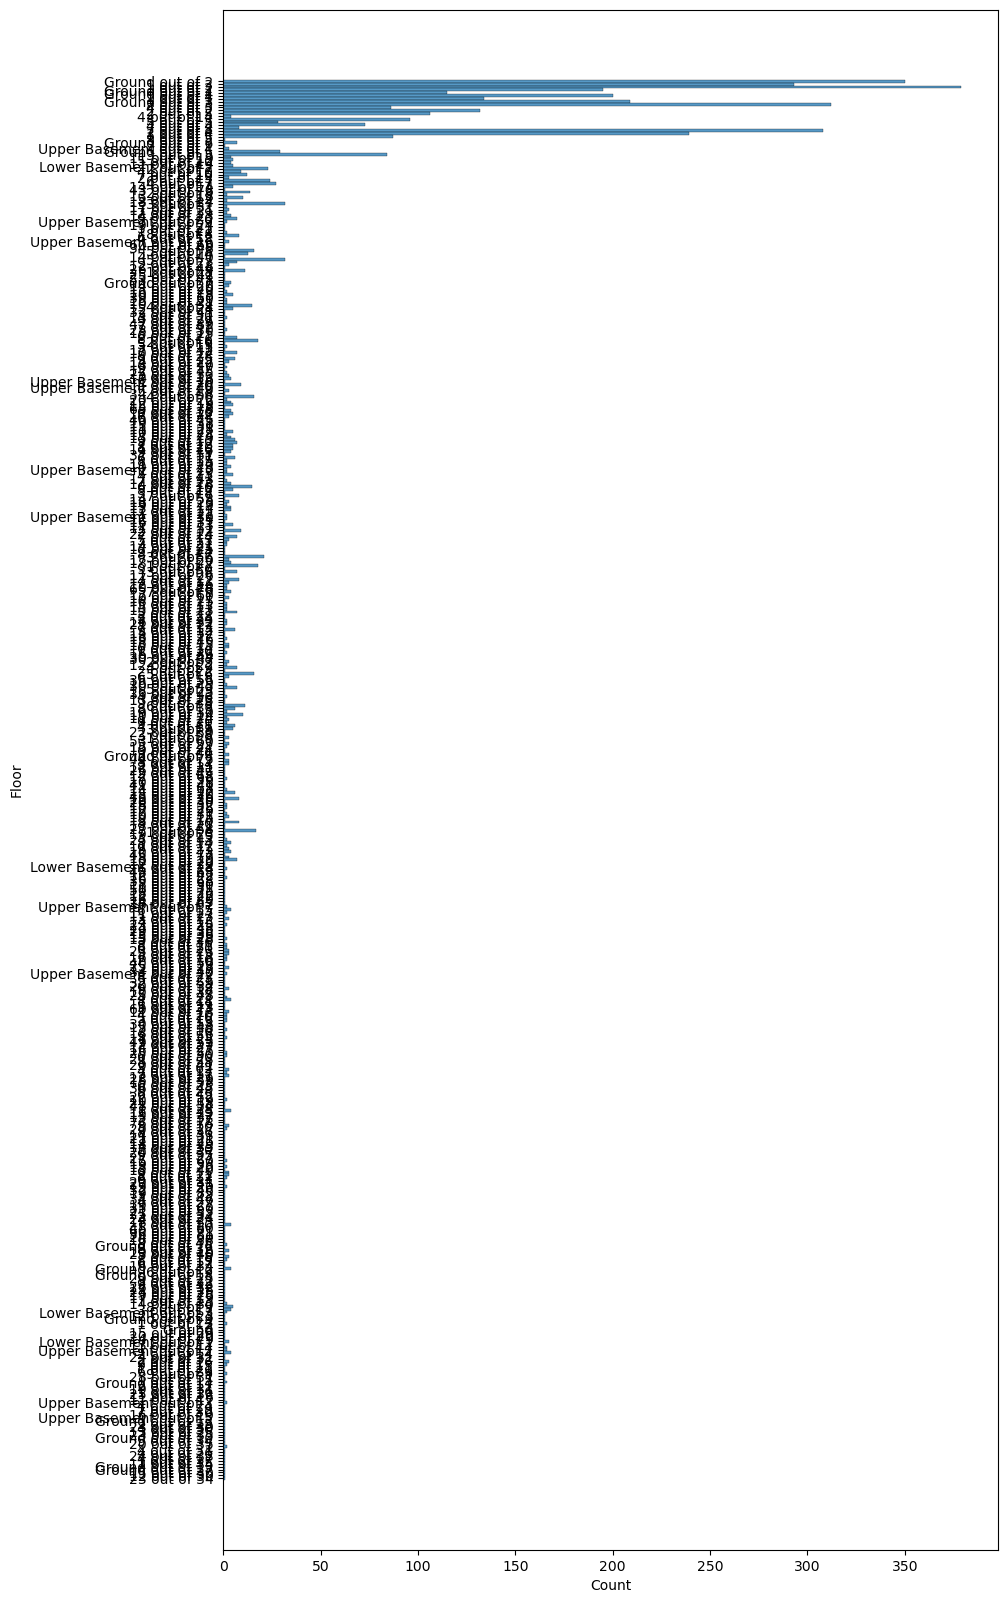

In [46]:
plt.figure(figsize=(10, 20))
sns.histplot(df, y='Floor');

Debido a la mala visualizacion de la grafica, agrupamos los tipos de floor en grupos para asi obtener una mejor vista.

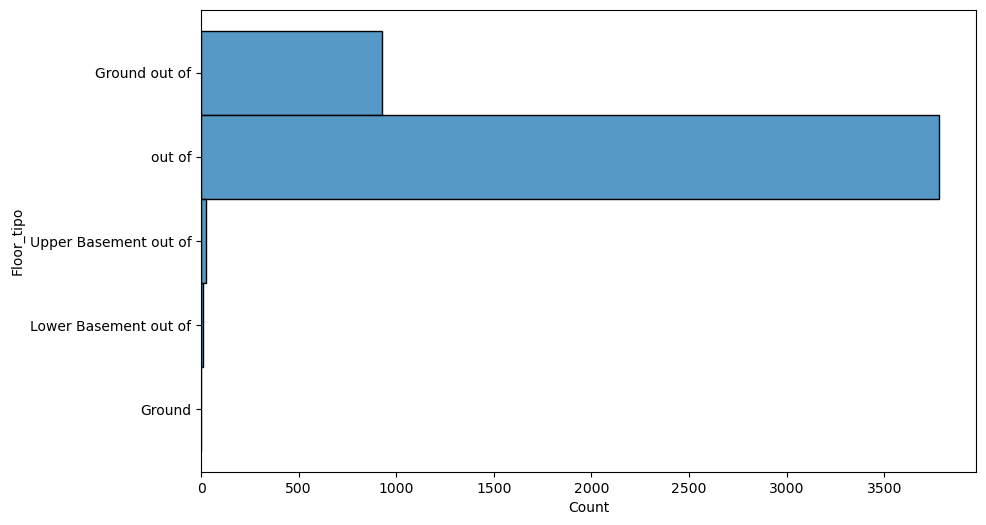

In [ ]:
# extraer solo el tipo del piso 
df['Floor_tipo'] = df['Floor'].str.extract(r'([a-zA-Z\s]+)')
df['Floor_tipo'] = df['Floor_tipo'].str.strip()

plt.figure(figsize=(10, 6))
sns.histplot(df, y='Floor_tipo')
plt.show()

__Histograma de Area Type__

In [49]:
df['Area Type'].value_counts()

Area Type
Super Area     2446
Carpet Area    2298
Built Area        2
Name: count, dtype: int64

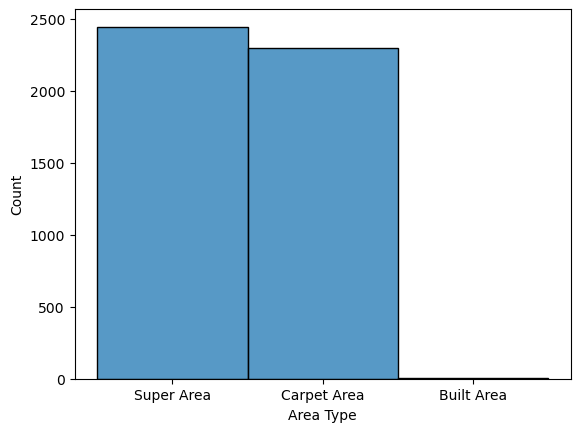

In [48]:
sns.histplot(df, x='Area Type');

__Histograma de Area Locality__

In [50]:
df['Area Locality'].value_counts()

Area Locality
Bandra West                       37
Gachibowli                        29
Electronic City                   24
Miyapur, NH 9                     22
Velachery                         22
                                  ..
Hoysala Nagar                      1
Nagarabhavi                        1
Shamanna Garden, Wilson Garden     1
Jagadish Nagar, Kaggadasapura      1
Purba Sinthi Area                  1
Name: count, Length: 2235, dtype: int64

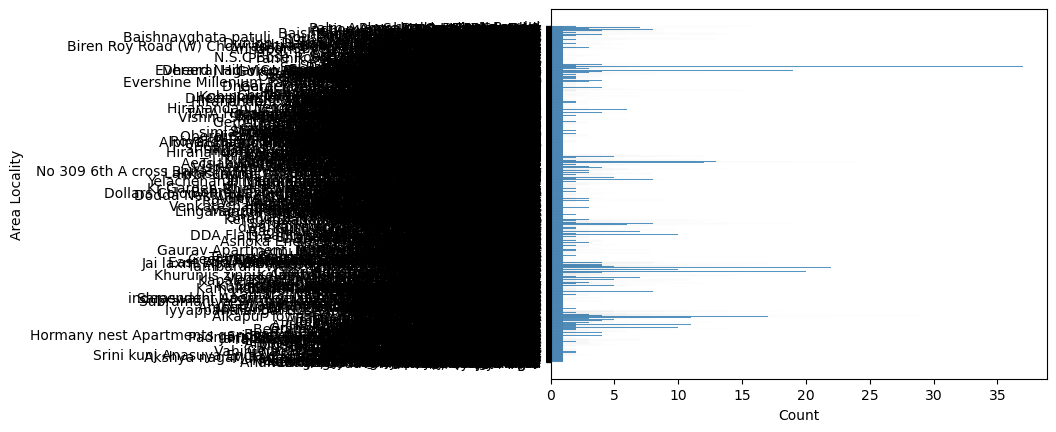

In [51]:
sns.histplot(df, y='Area Locality');

Debido a la gran cantidad de localidades, vamos a mostrar las 20 areas con mayor cantidad de inmuebles.

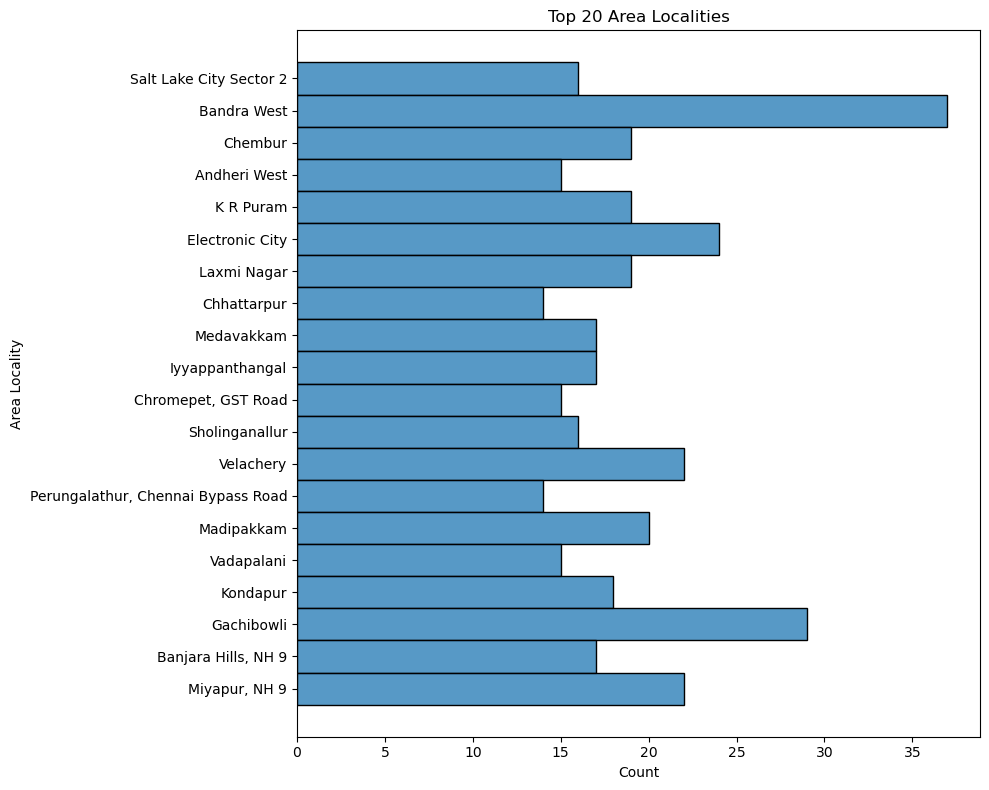

In [52]:
top_n = 20
top_localidades = df['Area Locality'].value_counts().nlargest(top_n).index

plt.figure(figsize=(10, 8))
sns.histplot(df[df['Area Locality'].isin(top_localidades)], y='Area Locality')
plt.title(f'Top {top_n} Area Localities')
plt.tight_layout()
plt.show()

__Histograma de City__

In [53]:
df.City.value_counts()

City
Mumbai       972
Chennai      891
Bangalore    886
Hyderabad    868
Delhi        605
Kolkata      524
Name: count, dtype: int64

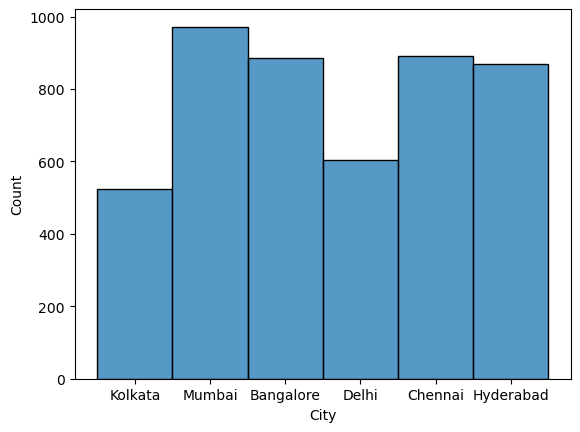

In [54]:
sns.histplot(df, x='City');

__Histograma de Furnishing Status__

In [55]:
df['Furnishing Status'].value_counts()

Furnishing Status
Semi-Furnished    2251
Unfurnished       1815
Furnished          680
Name: count, dtype: int64

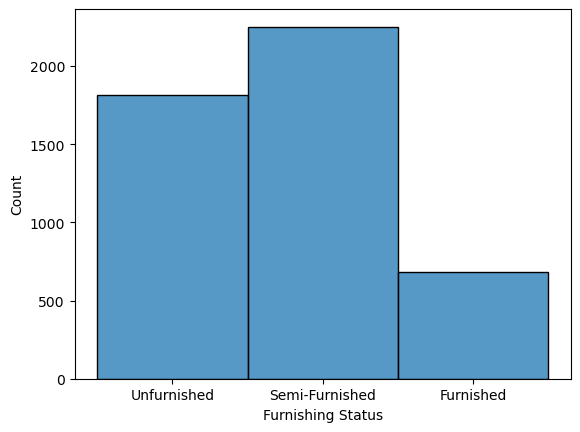

In [57]:
sns.histplot(df, x='Furnishing Status');

__Histograma de Tenant referred__

In [59]:
df['Tenant Preferred'].value_counts()

Tenant Preferred
Bachelors/Family    3444
Bachelors            830
Family               472
Name: count, dtype: int64

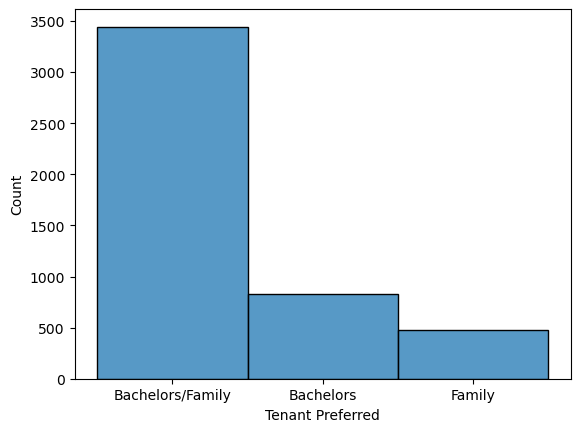

In [60]:
sns.histplot(df, x='Tenant Preferred');

__Histograma de Point of Contact__

In [61]:
df['Point of Contact'].value_counts()

Point of Contact
Contact Owner      3216
Contact Agent      1529
Contact Builder       1
Name: count, dtype: int64

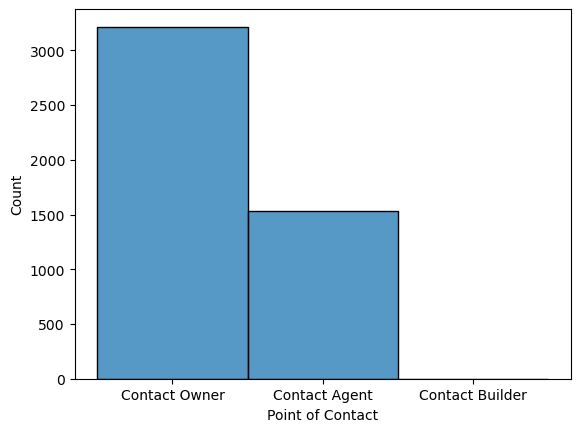

In [62]:
sns.histplot(df, x='Point of Contact');

## Tarea 5

Calcular la media y la desviacion estandar de las variables numericas

In [64]:
df.select_dtypes(include='number').describe().loc[['mean', 'std']]

,BHK,Rent,Size,Bathroom
mean,2.083860,34993.451327,967.490729,1.965866
std,0.832256,78106.412937,634.202328,0.884532
